## NLP Home Assignment - 2
### Name: Haaris Khalil
### Matriculation Number: 100006641

In [1]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras.models import Sequential # Takes the layer one by 1
from tensorflow.keras.layers import Dense # Creates a fully connected layers

In [2]:
# Sample Dataset
texts = [
    # Positive
    "I love this movie",
    "Excellent story",
    "I love chicken",
    "This is amazing and wonderful",
    "Best experience ever",
    "Absolutely fantastic work",

    # Negative
    "I hate this movie",
    "Mcdonalds is bad",
    "Terrible service and rude staff",
    "This is the worst thing ever",
    "Awful experience never again",
    "I really dislike this product",

    # Neutral
    "It's a really good movie but very lengthy",
    "Loved the storyline but not the cinematography.",
    "Superb product but not really healthy",
    "Loved this a lot but not much."
]

# Create labels
# 1 is neutral (Previously positive)
# 0 is negative
# 2 is positive 

labels = np.array([2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

# One-hot encode them
from tensorflow.keras.utils import to_categorical
labels_onehot = to_categorical(labels, num_classes=3)

# Create a tf-idf vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the texts into TF-IDF features
tfidf_matrix = vectorizer.fit_transform(texts)

# See the results
print("Feature names:", vectorizer.get_feature_names_out())
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("TF-IDF matrix:\n", tfidf_matrix.toarray())

Feature names: ['absolutely' 'amazing' 'awful' 'bad' 'best' 'chicken' 'cinematography'
 'dislike' 'excellent' 'experience' 'fantastic' 'good' 'hate' 'healthy'
 'lengthy' 'lot' 'love' 'loved' 'mcdonalds' 'movie' 'product' 'really'
 'rude' 'service' 'staff' 'story' 'storyline' 'superb' 'terrible' 'thing'
 'wonderful' 'work' 'worst']
TF-IDF matrix shape: (16, 33)
TF-IDF matrix:
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.7452182  0.
  0.         0.66682069 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.70710678 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.70710678 0.         0.        

In [3]:
model = Sequential()
model.add(Dense(7, activation='relu', input_shape=(tfidf_matrix.shape[1],)))
# output layer
model.add(Dense(3, activation='softmax'))

# changed from binary_crossentropy to categorical as we are using 3 labels now
model.compile(
    optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
)

c:\Users\abc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
history = model.fit(tfidf_matrix, labels_onehot, epochs=250, verbose=0)

In [5]:
new_text = ["it is popular so, why not?"]
new_vector = vectorizer.transform(new_text).toarray()
prediction = model.predict(new_vector)

class_names = ["Negative", "Neutral", "Positive"]
predicted_class = np.argmax(prediction[0])

print("Probabilities:", prediction[0])
print("Prediction:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Probabilities: [0.3173675  0.31400603 0.36862645]
Prediction: Positive


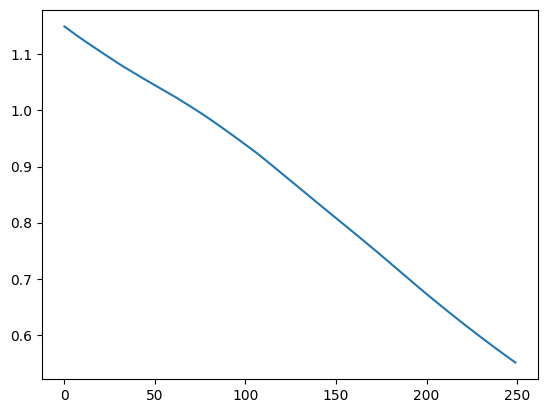

In [6]:
import matplotlib.pyplot as plt

# Training loss
plt.plot(history.history['loss'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step


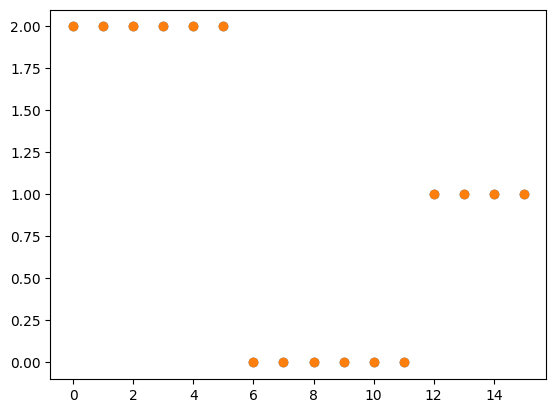

In [7]:
predictions = np.argmax(model.predict(tfidf_matrix), axis=1)
plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()